# **DP bedload model in 2d: Scaling analysis**

<hr>

## Preliminaries

In [1]:
from essentials import *
viz = Viz(dpi=100)

n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float
n_lattices: int
lattices: NDArray
tracking: NDArray

In [2]:
def plot(viz, expt, parameters, tracking,) -> None:
    name = make_name(parameters, "ρmean", None,)
    # title = make_title(parameters, None,)
    title = rf"$p_1={expt['p_1']}$  $p_2={expt['p_2']}$  $n={expt['n_iterations']}$"
    δ = 0.45051
    scale = expt["scale"]
    viz.lattice_statistic(
        name,
        title,
        tracking,
        choices=("time", "ρ_mean"),
        labels=None,
        #     "Order parameter  $\\widebar{\\rho}(t)$", 
        #     "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        #     "${\\delta}$",
        # ),
        exponent=-δ, 
        scale=scale,
        i_offset=0,
        do_ref_curve=True,
        fig_size=(4, 3,),
    )
    # plt.ylim(None, 1)
    plt.show()

In [3]:
def fit_tail(parameters, tracking) -> tuple[float, float]:
    i_offset: int = parameters.n_iterations//5
    t: NDArray = tracking["time"][i_offset:]
    ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
    (exponent, scale, r_value, p_value, std_err) \
        = linregress(np.log(t), np.log(ρ_mean))
    # print(f"t range: {t[0]}-{t[-1]}")
    print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")
    return (float(exponent), float(scale),)

In [4]:
def compute_tail_mean(parameters,) -> float:
    i_offset: int = parameters.n_iterations//2
    t: NDArray = tracking["time"][i_offset:]
    ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
    mean_ρ_mean: float = np.mean(ρ_mean)
    print(f"t range: {t[0]}-{t[-1]}")
    print(f"Tail mean: <ρ> = {(mean_ρ_mean):e}")
    # print(f"External:  p_conj = {(parameters.p_conj):g}")
    # print(f"Tail mean/p3:  <ρ>/p_conj = {round(mean_ρ_mean/parameters.p_conj, 1)}")
    return float(mean_ρ_mean)

<hr>

## Parameters

### Previous expts

In [5]:
do_recompute: bool = True
do_p2 = False

In [6]:
n_xy = 500

if do_p2:
    n_iterations = 5_000
    expts_tuple = (
        dict(p_1=0.575,    p_2=0.90, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.33777937520284457,),
        dict(p_1=0.575,    p_2=0.990, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.2690118062705938,),
        dict(p_1=0.575,    p_2=0.70, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.20681123976960433,),
        dict(p_1=0.575,    p_2=0.60, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.14921053984234472,),
        dict(p_1=0.575,    p_2=0.55, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.1198474710856365,),
        dict(p_1=0.575,    p_2=0.50, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.08733582438841975,),
        dict(p_1=0.575,    p_2=0.45, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.04876168936459232,),
        dict(p_1=0.575,    p_2=0.41, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.017081640350901265,),
        dict(p_1=0.575,    p_2=0.40, n_xy=n_xy, n_iterations=50_000, seed=1, scale=1, mean_ρ=0.00047958647360423124,),
    )
    grouped_expts = {
        expt["p_2"]: expt for i, expt in enumerate(expts_tuple)
    }
else:
    n_iterations = 5_000
    nm_iterations = 5_000
    m_iterations = 5_000
    # nm_iterations = 50_000
    # m_iterations = 200_000

    expts_tuple = (
        # dict(p_1=1.00,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=1.0,),
        # dict(p_1=0.95,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9283010082955488,),
        # dict(p_1=0.90,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.8517892698039058,),
        # dict(p_1=0.85,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.7694662109561616,),
        # dict(p_1=0.80,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.6797660745261225,),
        # dict(p_1=0.75,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.5800302321673775,),
        # dict(p_1=0.70,    p_2=0.0, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.46548806422870975,),
        # dict(p_1=0.65,    p_2=0.0, n_xy=n_xy, n_iterations=nm_iterations, seed=1, scale=1, mean_ρ=0.32405856854226567,),
        # dict(p_1=0.62,    p_2=0.0, n_xy=n_xy, n_iterations=nm_iterations, seed=1, scale=1, mean_ρ=0.21006421379595672,),
        # dict(p_1=0.60,    p_2=0.0, n_xy=n_xy, n_iterations=nm_iterations, seed=1, scale=1, mean_ρ=0.09347113744659502,),
        # dict(p_1=0.595,   p_2=0.0, n_xy=n_xy, n_iterations=nm_iterations, seed=1, scale=1, mean_ρ=0.04013863534664404,),
        dict(p_1=0.5945,  p_2=0.0, n_xy=n_xy, n_iterations=20000, seed=1, scale=1, mean_ρ=0.033163711336456216,),
        # dict(p_1=0.594,   p_2=0.0, n_xy=n_xy, n_iterations=nm_iterations, seed=1, scale=1, mean_ρ=0.02358432381036714,),
        # dict(p_1=0.5935,  p_2=0.0, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.007081959606105384,),
        # dict(p_1=0.5934,  p_2=0.0, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.004614760772485601,),
        # dict(p_1=0.59337, p_2=0.0, n_xy=n_xy, n_iterations=50_000, seed=1, scale=1, mean_ρ=0.007280740645192801,),
        # dict(p_1=0.58,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, mean_ρ=0,),
        dict(p_1=0.56,   p_2=0.0, n_xy=n_xy, n_iterations=5000, seed=1, scale=1, mean_ρ=0,),
        # dict(p_1=0.51,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, mean_ρ=0,),
        # dict(p_1=0.45,   p_2=0.0, n_xy=n_xy, n_iterations=30_000, seed=1, scale=1, mean_ρ=0,),
    )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.478516e-01,),
    #     dict(p_1=0.90,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.898342e-01,),
    #     dict(p_1=0.85,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.244839e-01,),
    #     dict(p_1=0.80,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.499310e-01,),
    #     dict(p_1=0.75,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=6.630610e-01,),
    #     dict(p_1=0.70,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=5.582801e-01,),
    #     dict(p_1=0.65,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=4.251317e-01,),
    #     dict(p_1=0.60,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=2.279497e-01,),
    #     dict(p_1=0.5900,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.384130e-02,),
    #     dict(p_1=0.5890,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.430133e-02,),
    #     dict(p_1=0.5880,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=6.285815e-02,),
    #     dict(p_1=0.5870,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=4.646714e-02,),
    #     dict(p_1=0.5860,    p_2=0.2, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=3.436060e-02,),
    #     dict(p_1=0.5850,    p_2=0.2, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=1.899029e-02,),
    #     dict(p_1=0.5840,    p_2=0.2, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=,),
    #     dict(p_1=0.5838,    p_2=0.2, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.478516e-01,),
    #     dict(p_1=0.90,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.898342e-01,),
    #     dict(p_1=0.85,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.244839e-01,),
    #     dict(p_1=0.80,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.499310e-01,),
    #     dict(p_1=0.75,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=6.630610e-01,),
    #     dict(p_1=0.70,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=5.582801e-01,),
    #     dict(p_1=0.65,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=4.251317e-01,),
    #     dict(p_1=0.60,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=2.279497e-01,),
    #     dict(p_1=0.58,    p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.289189e-02,),
    #     dict(p_1=0.579,   p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.347947e-02,),
    #     dict(p_1=0.578,   p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=5.583668e-02,),
    #     dict(p_1=0.577,   p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=3.998964e-02,),
    #     dict(p_1=0.5760,  p_2=0.4, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=1.212315e-02,),
    #     dict(p_1=0.5755,  p_2=0.4, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0,),
    #     dict(p_1=0.5750,  p_2=0.4, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.579307e-01,),
    #     dict(p_1=0.90,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.101171e-01,),
    #     dict(p_1=0.85,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.549435e-01,),
    #     dict(p_1=0.80,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.903465e-01,),
    #     dict(p_1=0.75,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.129436e-01,),
    #     dict(p_1=0.70,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=6.169763e-01,),
    #     dict(p_1=0.65,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=4.915130e-01,),
    #     dict(p_1=0.60,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=3.059556e-01,),
    #     dict(p_1=0.57,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.861621e-02,),
    #     dict(p_1=0.5655,    p_2=0.6, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=1.753605e-02,),
    #     dict(p_1=0.5653,    p_2=0.6, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0,),
    #     dict(p_1=0.5650,    p_2=0.6, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.682188e-01,),
    #     dict(p_1=0.90,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.313078e-01,),
    #     dict(p_1=0.85,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.876666e-01,),
    #     dict(p_1=0.80,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.351150e-01,),
    #     dict(p_1=0.75,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.701547e-01,),
    #     dict(p_1=0.70,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=6.869096e-01,),
    #     dict(p_1=0.65,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=5.741579e-01,),
    #     dict(p_1=0.60,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=4.033921e-01,),
    #     dict(p_1=0.57,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=2.324365e-01,),
    #     dict(p_1=0.56,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=1.411233e-01,),
    #     dict(p_1=0.555,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=6.739605e-02,),
    #     dict(p_1=0.554,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=5.236005e-02,),
    #     dict(p_1=0.553,    p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=6.592255e-03,),
    #     dict(p_1=0.552,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0,),
    # )

    # expts_tuple = (
    #     dict(p_1=1.00,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=1.0,),
    #     dict(p_1=0.95,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.782101e-01,),
    #     dict(p_1=0.90,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.523538e-01,),
    #     dict(p_1=0.85,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=9.210114e-01,),
    #     dict(p_1=0.80,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.821824e-01,),
    #     dict(p_1=0.75,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=8.326867e-01,),
    #     dict(p_1=0.70,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=7.668132e-01,),
    #     dict(p_1=0.65,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=6.735684e-01,),
    #     dict(p_1=0.60,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=5.264920e-01,),
    #     dict(p_1=0.55,    p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=2.175521e-01,),
    #     dict(p_1=0.540,   p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=5.808012e-02,),
    #     dict(p_1=0.539,   p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=7.494072e-03,),
    #     dict(p_1=0.5385,  p_2=0.99, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0,),
    # )

    grouped_expts = {
        expt["p_1"]: expt for i, expt in enumerate(expts_tuple)
    }
    # [{expt["p_2"]: expt["mean_ρ"]} for expt in grouped_expts.values()]


### Model C:  $\,\,$ $p_1$ variation, $\,$ $p_2 = 0.7$

In [7]:
# do_recompute: bool = False
# do_p2 = False
# n_xy = 500
# raw_title = "Bedload model C"
# raw_name = "bedloadc"

# n_iterations = 5_000
# # m_iterations = 5_000
# m_iterations = 25_000
# expts_tuple = (
#     dict(p_1=0.99, p_2=0.75, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9849184723865123,),
#     dict(p_1=0.95, p_2=0.75, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9188720611322884,),
#     dict(p_1=0.90, p_2=0.75, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.8213868246036546,),
#     dict(p_1=0.85, p_2=0.75, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.704247731916526,),
#     dict(p_1=0.80, p_2=0.75, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.5626327630902519,),
#     dict(p_1=0.75, p_2=0.75, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.3845782841338677,),
#     dict(p_1=0.72, p_2=0.75, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.24097730921808314,),
#     dict(p_1=0.70, p_2=0.75, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.08756235772209657,),
#     dict(p_1=0.698, p_2=0.75, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.061552826287152626,),
#     dict(p_1=0.6957, p_2=0.75, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.013645361600558898,),
# )
# p_c = 0.6957
# p_0 = 0.65
# p_min = 0.65
# ρ_max = 1.01
# Δp = 2e-3
# sf = 1.04
# φ_scale = 1.2
# grouped_expts = {
#     expt["p_1"]: expt for i, expt in enumerate(expts_tuple)
# }

### Model C:  $\,\,$ $p_2$ variation, $\,$ $p_1 = 0.7$

In [8]:
# do_recompute: bool = False
# do_p2 = True
# n_xy = 500
# raw_title = "Bedload model C"
# raw_name = "bedloadc"

# n_iterations = 5_000
# m_iterations = 25_000
# expts_tuple = (
#     dict(p_1=0.7, p_2=0.99, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.567131322557952,),
#     dict(p_1=0.7, p_2=0.95, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.5204482294949757,),
#     dict(p_1=0.7, p_2=0.90, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.45297373806843994,),
#     dict(p_1=0.7, p_2=0.85, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.3712771126314527,),
#     dict(p_1=0.7, p_2=0.80, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.26499830514657313,),
#     dict(p_1=0.7, p_2=0.79, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.23839412356128412,),
#     dict(p_1=0.7, p_2=0.78, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.2090554994935753,),
#     dict(p_1=0.7, p_2=0.77, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.17625667328169134,),
#     dict(p_1=0.7, p_2=0.76, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.13860194245632626,),
#     dict(p_1=0.7, p_2=0.75, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.08756235772209657,),
#     dict(p_1=0.7, p_2=0.745, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.052424328467095625,),
#     dict(p_1=0.7, p_2=0.7415, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.013607971214552756,),
# )
# p_c = 0.7415
# p_0 = 0.7
# p_min = 0.7
# ρ_max = 0.6
# Δp = 2e-3
# sf = 0.63
# φ_scale = 0.7
# grouped_expts = {
#     expt["p_2"]: expt for i, expt in enumerate(expts_tuple)
# }

### Model C:  $\,\,$ $p_2$ variation, $\,$ $p_1 = 0.96693$

In [9]:
do_recompute: bool = False
do_p2 = True
n_xy = 500
raw_title = "Bedload model C"
raw_name = "bedloadc"

n_iterations = 5_000
m_iterations = 25_000
expts_tuple = (
    dict(p_1=0.96693, p_2=0.90, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9628364671139372,),
    dict(p_1=0.96693, p_2=0.80, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9536004426335393,),
    dict(p_1=0.96693, p_2=0.70, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9415942895464876,),
    dict(p_1=0.96693, p_2=0.60, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9253339900678751,),
    dict(p_1=0.96693, p_2=0.50, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.9021482209308964,),
    dict(p_1=0.96693, p_2=0.40, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.8663496838622644,),
    dict(p_1=0.96693, p_2=0.30, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.80390563131761,),
    dict(p_1=0.96693, p_2=0.25, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.7514592577151802,),
    dict(p_1=0.96693, p_2=0.20, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.6685795963215666,),
    dict(p_1=0.96693, p_2=0.17, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.5905585025177628,),
    dict(p_1=0.96693, p_2=0.15, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.5169643654865248,),
    dict(p_1=0.96693, p_2=0.14, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.46988281557579986,),
    dict(p_1=0.96693, p_2=0.13, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.41205984554210695,),
    dict(p_1=0.96693, p_2=0.12, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.3383208756468764,),
    dict(p_1=0.96693, p_2=0.11, n_xy=n_xy, n_iterations=n_iterations, seed=1, scale=1, mean_ρ=0.23636767567276526,),
    dict(p_1=0.96693, p_2=0.10, n_xy=n_xy, n_iterations=m_iterations, seed=1, scale=1, mean_ρ=0.03271850694080285,),
)
p_c = 0.0965
p_0 = 0.05
p_min = 0.0
ρ_max = 1.01
Δp = 1e-2
sf = 2.8
φ_scale = 1.02
grouped_expts = {
    expt["p_2"]: expt for i, expt in enumerate(expts_tuple)
}

### Set parameters

In [10]:
def set_parameters(expt):
    class Parameters:
        growth_model = GrowthModel.BedloadC
        dim = Dimension.D2
        n_x: int = expt["n_xy"]
        n_y: int = expt["n_xy"]
        n_z: int = 1
        p_1: float = expt["p_1"]
        p_2: float = expt["p_2"]
        p_conj: float = 0 # 1e-4
        p_nbr: float = 0.5
        p_diag: float = 0.1
        n_iterations: int = expt["n_iterations"] 
        sample_period: int = 0
        random_seed: int = expt["seed"] if expt["seed"] is not None else 1
        # initial_condition = InitialCondition.CentralCell
        # initial_condition = InitialCondition.EdgeCell
        initial_condition = InitialCondition.Randomized
        p_initial: float = 0.1
        topology_x = Topology.Periodic
        topology_y = Topology.Periodic
        topology_z = Topology.Unspecified
        bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
        bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
        bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
        bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
        bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
        bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
        do_edge_buffering: bool = True
        processing = Processing.Parallel
        n_threads: int = 16
    return Parameters()

<hr>

## Analysis

In [11]:
if do_recompute:
    for p_choice in grouped_expts.keys():
        print(f"{'p_2' if do_p2 else 'p_1'} = {p_choice}", flush=True,)
        expt = grouped_expts[p_choice]
        parameters = set_parameters(expt)

        (n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)
        # print(f"Total number of lattice time slices = {n_raw_lattices}\n")
        (n_lattices, lattices, tracking) \
            = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)

        # (exponent, scale,) = fit_tail(parameters, tracking)
        # grouped_expts[p1_choice]["scale"] = scale if mean_ρ<1e-3 else 1
        mean_ρ = compute_tail_mean(parameters)
        grouped_expts[p_choice]["mean_ρ"] = mean_ρ
        plot(viz, expt, parameters, tracking,)

In [12]:
pp(grouped_expts)

{   0.1: {   'mean_ρ': 0.03271850694080285,
             'n_iterations': 25000,
             'n_xy': 500,
             'p_1': 0.96693,
             'p_2': 0.1,
             'scale': 1,
             'seed': 1},
    0.11: {   'mean_ρ': 0.23636767567276526,
              'n_iterations': 5000,
              'n_xy': 500,
              'p_1': 0.96693,
              'p_2': 0.11,
              'scale': 1,
              'seed': 1},
    0.12: {   'mean_ρ': 0.3383208756468764,
              'n_iterations': 5000,
              'n_xy': 500,
              'p_1': 0.96693,
              'p_2': 0.12,
              'scale': 1,
              'seed': 1},
    0.13: {   'mean_ρ': 0.41205984554210695,
              'n_iterations': 5000,
              'n_xy': 500,
              'p_1': 0.96693,
              'p_2': 0.13,
              'scale': 1,
              'seed': 1},
    0.14: {   'mean_ρ': 0.46988281557579986,
              'n_iterations': 5000,
              'n_xy': 500,
              'p_1': 0.96693,
  

In [13]:
p1_ρ = np.array([
    (v["p_1"], v["mean_ρ"]) for v in grouped_expts.values()
]).T
p2_ρ = np.array([
    (v["p_2"], v["mean_ρ"]) for v in grouped_expts.values()
]).T

<hr>

## Visualization

### Percolation scaling

In [14]:
def plot_ρ_p(
        x: NDArray, y: NDArray, 
        p_c: float=0, #p_0: float, 
        name:str="", title:str="",
        do_loglog=False, do_p2=False, do_model=True,
        p_min: float=0.7, ρ_max: float=1.03, Δp: float=2e-3,
        sf=1, 
    ):
    name += "_loglog" if do_loglog else ""
    _ = viz.create_figure(fig_name=name, fig_size=(4.5, 3.5,),)
    if do_p2:
        x_label = rf"Collective entrainment  $p_2$"
    else:
        x_label = rf"Hop survival  $p_1$"
    plt.title(title, fontdict={"fontsize": 11.5}, y=1.03,)
    β = 0.5834
    if do_model:
        if do_loglog:
            pass
            # Δp = (2e-3 if do_p2 else 2e-3)
        else:
            Δp = 1e-5
        p = np.linspace(p_c+Δp, 1, 1001, endpoint=True,)
        ρ_mean =  ((p-p_c)*np.heaviside(p-p_c,0))**β / (1-p_c)**β * sf
        x_model = p - (p_c if do_loglog else 0)
        y_model = ρ_mean
        plt.plot(
            x_model, y_model,
            ("r" if do_p2 else "b") , lw=2, alpha=0.4, 
            label=r"$\overline{\rho} \sim |$"+f"{'$p_2$' if do_p2 else '$p_1$'}"+r"$ - p_c|^{0.5834}$",
        )
    offset = -1 if do_loglog else -1
    plt.plot(x[:offset] - (p_c if do_loglog else 0), y[:offset], "ko", ms=5, lw=1,)
    if do_loglog:
        plt.loglog()
        plt.ylim(None, ρ_max,)
    else:
        plt.ylim(0, ρ_max,)
        plt.xlim(p_min, 1,)
    plt.xlabel(x_label)
    plt.ylabel(r"Asymptotic  $\widebar\rho(t)$ [-]")
    plt.legend()
    plt.grid(ls=":")

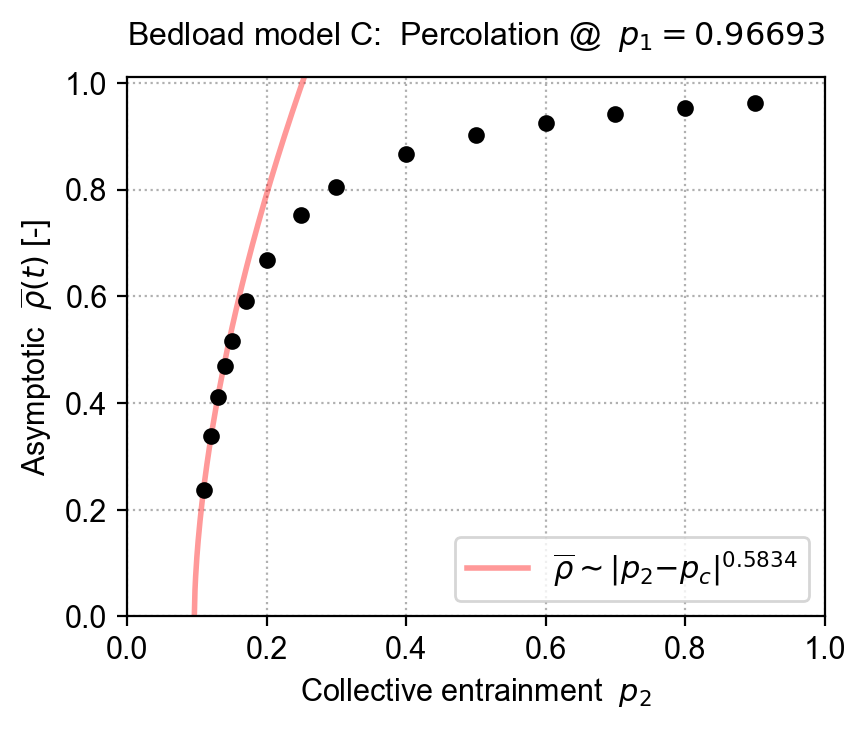

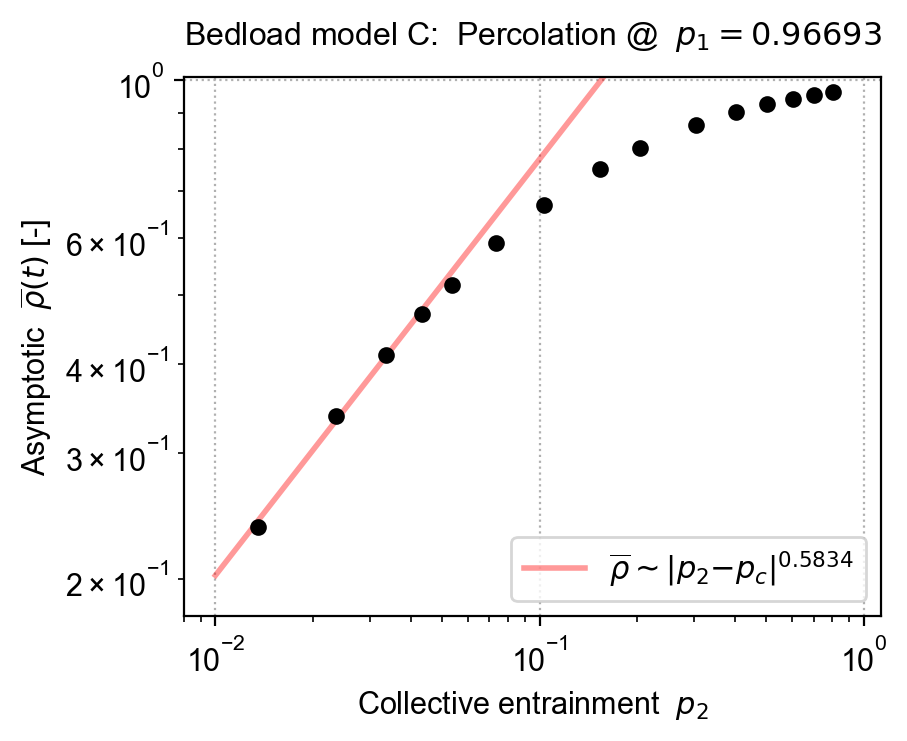

In [15]:
if do_p2:
    p_1 = float(p1_ρ[0,0])
    name = raw_name + f"_percolation_p1fixed{p_1}".replace(".","p")
    title = raw_title + f":  Percolation @  $p_1={p_1}$"
    p_ρ = p2_ρ
else:
    p_2 = float(p2_ρ[0,0])
    name = raw_name + f"_percolation_p2fixed{p_2}".replace(".","p")
    title = raw_title + f":  Percolation @  $p_2={p_2}$"
    p_ρ = p1_ρ

plot_ρ_p(
    p_ρ[0, :], p_ρ[1, :], p_c,
    name=name, title=title,
    do_loglog=False, do_p2=do_p2, do_model=True,
    p_min=p_min, Δp=Δp, ρ_max=ρ_max, sf=sf, 
)
plot_ρ_p(
    p_ρ[0, :], p_ρ[1, :], p_c, 
    name=name, title=title,
    do_loglog=True, do_p2=do_p2, do_model=True, 
    p_min=p_min, Δp=Δp, ρ_max=ρ_max, sf=sf, 
)

### Deduced bedload flux vs Shields stress

In [16]:
def plot_φ_τ(
        τ: NDArray, φ: NDArray, 
        τ_c: float, τ_0: float, φ_scale: float=1.7,
        name:str="", title:str="",
        do_loglog=False,
    ):
    fig = viz.create_figure(fig_name=name, fig_size=(4.5, 3.5,),)
    plt.title(title, fontdict={"fontsize": 11.5}, y=1.03,)
    plt.plot(τ, φ, "ko", ms=5, lw=1,)
    τ_model = np.linspace(0, 1, 5001, endpoint=True,)
    β = 0.5834
    # β = 0.5
    # φ_model = φ_scale * ((τ_model-τ_c)*np.heaviside(τ_model-τ_c,0))**β
    φ_model = φ_scale * ((τ_model-τ_c)*np.heaviside(τ_model-τ_c,0))**β * τ_model**1
    offset = 1
    x = τ_model[offset:]
    y = φ_model[offset:]
    plt.plot(
        x, y, 
        "Brown", lw=2, alpha=0.4, label=r"$\overline{\rho} \sim |p_1 - p_c|^{0.5834}$",
    )
    plt.ylabel(r"Deduced Einstein number   $\varphi^{\!*}$   $[-]$")
    plt.xlabel(r"Deduced Shields stress   $\tau^{\!*}$   $[-]$")
    if do_loglog:
        plt.loglog()
    else:
        plt.semilogy()
    plt.grid(ls=":")

In [17]:
if do_p2:
    p = p2_ρ[0, :]
    ρ = p2_ρ[1, :]
    p_c = float(p_ρ.T[-1][0])
else:
    p = p1_ρ[0, :]
    ρ = p1_ρ[1, :]

if do_p2:
    τ = (p - p_0)
    τ_c = (p_c - p_0)
    τ_0 = p_0
else:
    τ = (p - p_0)/1.9
    τ_c = (p_c - p_0)/1.9
    τ_0 = p_0/1.9

φ = ρ * τ**1.5

In [18]:
if do_p2:
    p_1 = float(p1_ρ[0,0])
    name = raw_name + f"_flux_p1fixed{p_1}".replace(".","p")
    title = raw_title + r" flux $\widebar\varphi^{\!*}(\!\tau^{\!*}\!)$ @  "+rf"$p_1={p_1}$"
else:
    p_2 = float(p2_ρ[0,0])
    name = raw_name + f"_flux_p2fixed{p_2}".replace(".","p")
    title = raw_title + r" flux $\widebar\varphi^{\!*}(\!\tau^{\!*}\!)$ @  "+rf"$p_2={p_2}$"


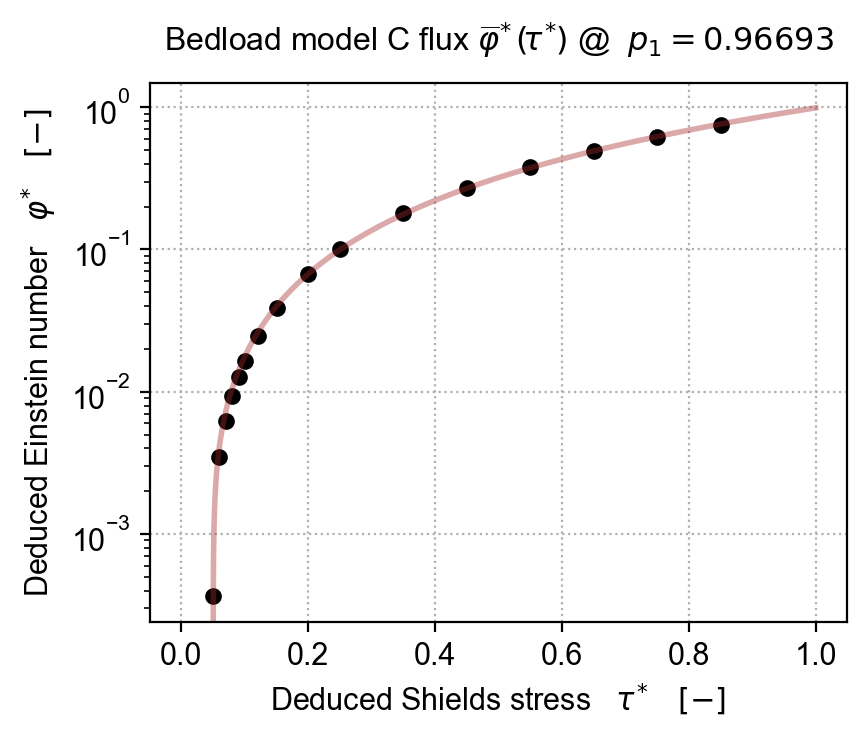

In [19]:
plot_φ_τ(τ, φ, τ_c, τ_0, φ_scale, name=name, title=title, do_loglog=False,)

<hr>

## Export

In [20]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "bedload2d")
print(tuple(viz.fdict.keys()))
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

('bedloadc_percolation_p1fixed0p96693', 'bedloadc_percolation_p1fixed0p96693_loglog', 'bedloadc_flux_p1fixed0p96693')


'././plots/bedload2d'